<p align="center">
    <img src="https://github.com/GeostatsGuy/GeostatsPy/blob/master/TCG_color_logo.png?raw=true" width="220" height="240" />

</p>

## **Demonstrating BiLSTM  architecture for sequential data modeling**

#### Alexander Ifenaike
#### Hildebrand Department of Petroleum and Geosystems Engineering, The University of Texas at Austin.

### Subsurface Machine Learning Course, The University of Texas at Austin
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering
#### Department of Geological Sciences, Jackson School of Geosciences

_____________________

Workflow supervision and review by:

#### **Instructor: Prof. Michael Pyrcz, Ph.D., P.Eng., Associate Professor, The Univeristy of Texas at Austin**
[Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

#### **Course TA: Maria Gonzalez, Graduate Student, The University of Texas at Austin**





### **Executive Summary**

This project demonstrates how a Bidirectional Long Short-Term Memory (BiLSTM) network can be used to model temporal patterns in sequential data. To illustrate this, we walk through the end-to-end process of building, training, and evaluating a BiLSTM model on real meteorological time-series data, showing how the architecture leverages information from both past and future directions in a sequence. The demonstration covers essential steps including data preprocessing, sliding window sequence creation, feature scaling, and hyperparameter tuning to show how each component contributes to model development and performance. The results highlight BiLSTM's ability to capture long-range temporal dependencies and produce stable next-day temperature forecasts, making them a strong choice for time-dependent prediction tasks.

### **Recurrent Neural Networks (RNNs)**


Recurrent Neural Networks are a type of neural network designed to work with sequential data, such as time series or text.
Unlike regular feed-forward networks, RNNs have a loop that allows information from previous time steps to be carried forward. This gives the model a simple form of memory, letting it learn patterns that unfold over time.





### What are **Bidirectional** Long-Short Term Memory Networks?

Long Short-Term Memory networks (LSTMs) are a type of recurrent neural network designed to process **sequential data** by maintaining information over time steps. A standard LSTM reads a sequence **in one direction** (from **past → present**) and learns temporal dependencies based solely on earlier values in the sequence.

However, some patterns are easier to learn when the model can also consider **later context** within the same input window. A **Bidirectional LSTM (BiLSTM)** extends the standard LSTM by running **two LSTMs in parallel** on the same sequence:

* a **forward LSTM** that processes the input sequence from start to end.
* a **backward LSTM** processes the input sequence from end to start.

Each time step therefore produces two hidden states (one from each direction) which are joined to form a single, richer representation that incorporates information from **both earlier and later positions** in the data sequence.


Formally, for an input sequence ($x_1, x_2, \dots, x_T$):

- The forward LSTM computes hidden states
  ( $\overrightarrow{h_t}$) for (t = 1, $\dots$, T )
- The backward LSTM computes hidden states
  ( $\overleftarrow{h_t}$ ) for ( t = T, $\dots$, 1 )

The final representation at time step ( t ) is the concatenation of both:
$$
h_t = [\overrightarrow{h_t},\ \overleftarrow{h_t}]
$$

This combined hidden state is then passed to the next layer, which is usually a **fully connected output layer** to map the merged representation to the model's final prediction.


![Bi-LSTM flow chart](https://miro.medium.com/v2/resize:fit:1360/format:webp/1*sf4vCzcyycSe7GC3dZ2u2w.png)

> **Citation:**
The image above was taken from the [Understanding Bidirectional LSTM for Sequential Data Processing](https://medium.com/@anishnama20/understanding-bidirectional-lstm-for-sequential-data-processing-b83d6283befc) article on medium.


### **Import Packages**



In [1]:
import numpy as np                                     # for working with data and model arrays
import pandas as pd                                    # for working with data and dataframes
import seaborn as sns                                  # for data visualization
from matplotlib import pyplot as plt                   # for data visualization
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf  # for partial auto-correlation and auto-correlation function plots.
from statsmodels.tsa.seasonal import seasonal_decompose        # seasonality and trend decomposition for response feature
from sklearn.preprocessing import MinMaxScaler                 # for feature scaling and transformation
import torch                                          # primary deep learning framework
import torch.nn as nn                                 # pytorch module to access neural network architectures
from torch.utils.data import Dataset, DataLoader      # pytorch module for creating sequenced data and handling batches
from torch.nn.utils import clip_grad_norm_            # to clip gradient for stability
import torch.optim as optim                           # pytorch module to access optimizer for neural network training
import torch.optim.lr_scheduler as lr_scheduler       # learning rate scheduler
from sklearn.model_selection import TimeSeriesSplit   # cross validation strategy that honors time series.
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error        # evaluation metric for regression
import math                                           # math computation
import os, random                                     # manage random seed and environment settings
from sklearn.model_selection import ParameterGrid #hyperparameter search space definition

We set all random seeds and enable deterministic algorithms so that our model produces the very similar results every time we run the workflow. Without these settings, small sources of randomness in NumPy, PyTorch, and CUDA could cause the training process to vary, making experiments inconsistent and hard to compare.

In [ ]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"  
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

### **Function**

The following function will be used in the workflow.
- **plot_predictions:** to visualize predictions versus ground truth.



In [3]:
# Plot True vs Predicted values for time series forecasting.
def plot_predictions(test_dates, true_vals, pred_vals, model_name="BiLSTM"):

    # Ensure 1D arrays
    true_vals = np.array(true_vals).flatten()
    pred_vals = np.array(pred_vals).flatten()

    # Compute metrics for annotation
    r2 = r2_score(true_vals, pred_vals)
    mae = mean_absolute_error(true_vals,pred_vals)
    mse = mean_squared_error(true_vals,pred_vals)
    rmse = np.sqrt(mse)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Line plot — True vs Predicted over time
    axes[0].plot(test_dates, true_vals, label='True Temperature', color='blue', linewidth=2)
    axes[0].plot(test_dates, pred_vals, label='Predicted Temperature', color='red', linestyle='--', linewidth=2)
    axes[0].set_title(f'{model_name}: True vs Predicted Over Time (Test Set)')
    axes[0].set_xlabel('Date'); axes[0].set_ylabel('Temperature (°C)')
    axes[0].legend()
    # Scatter plot — True vs Predicted
    axes[1].scatter(true_vals, pred_vals, color='purple', alpha=0.7)
    axes[1].plot([true_vals.min(), true_vals.max()], [true_vals.min(), true_vals.max()], 'r--', lw=2, label='Ideal Fit')
    axes[1].set_title(f'{model_name}: Predicted vs True Scatter')
    axes[1].set_xlabel('True Temperature (°C)'); axes[1].set_ylabel('Predicted Temperature (°C)')
    axes[1].legend()

    # Display metrics
    axes[1].text(0.05, 0.95,
                 f"R² = {r2:.3f}\nMAE = {mae:.2f}°C\nMSE = {mse:.2f}°C\nRMSE = {rmse:.2f}°C",
                 transform=axes[1].transAxes,
                 fontsize=10, verticalalignment='top',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7))

    plt.tight_layout()
    plt.show()

- **eval_original_units:** to obtain error measurements and predictions in the original units of the response features by reversing scaling.

In [4]:
def eval_original_units(preds, targs, scaler):
    performance_metrics = {}
    preds_inv  = scaler.inverse_transform(preds)
    targs_inv  = scaler.inverse_transform(targs)
    performance_metrics['MSE'] = mean_squared_error(targs_inv, preds_inv)
    performance_metrics['MAE'] = mean_absolute_error(targs_inv, preds_inv)
    performance_metrics['RMSE'] = math.sqrt(performance_metrics['MSE'])
    return preds_inv, targs_inv , performance_metrics

- **plot_epoch:** To plot the training and valudation losses over all epochs.

In [5]:
# Plot training and validation loss across epochs.
def plot_epoch(train_loss, val_loss, model_name = "Model", log_scale=False):
    epochs = np.arange(1, len(train_loss) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_loss, label='Training Loss', marker='o', linestyle='-', color='blue', linewidth=2)
    plt.plot(epochs, val_loss, label='Validation Loss', marker='x', linestyle='--', color='red', linewidth=2)

    plt.title(f"Training and Validation Loss per Epoch – {model_name}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (MSE)" + (" (log scale)" if log_scale else ""))
    plt.legend(); plt.grid(True, linestyle=':', alpha=0.6)
    if len(epochs) > 50:
      step =10
      plt.xticks(np.arange(0, len(epochs) + 1, step)) # show every 10 epochs on x-axis
    else:
      plt.xticks(epochs)  # show every epoch on x-axis

    if log_scale:
        plt.yscale("log")

    plt.tight_layout(); plt.show()

### **1. Load Data**

This workflow uses two files: **DailyDelhiClimateTrain.csv** and **DailyDelhiClimateTest.csv**. The dataset contains meteorological observations recorded in Delhi, India, spanning from January 1, 2013, to April 24, 2017.

It includes the following five features:
  - **date** Timestamp for measurement in year/mm/dd
  - **meantemp:** Mean daily temperature (°C), averaged from multiple 3-hour interval readings.
  - **humidity:** Daily average humidity (grams of water vapor per cubic meter of air).
  - **wind_speed:** Average wind speed (km/h).
  - **meanpressure:** Mean atmospheric pressure (atm).

The dataset is publicly available on [kaggle](http://kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data/data). It is already split into training and testing sets:
  - **Training set:** January 1, 2013 – December 31, 2016
  - **Testing set:** January 1, 2017 – April 23, 2017.

Let's combine both dataset for proper cleaning and analysis.



In [6]:
Train_df = pd.read_csv("https://raw.githubusercontent.com/aifenaike/PGE383_Project/refs/heads/main/dataset/DailyDelhiClimateTrain.csv")
Test_df = pd.read_csv("https://raw.githubusercontent.com/aifenaike/PGE383_Project/refs/heads/main/dataset/DailyDelhiClimateTest.csv")
data = pd.concat([Train_df, Test_df]) #join datasets
data = data.reset_index() #reset index
data.head()

,index,date,meantemp,humidity,wind_speed,meanpressure
0,0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


### **2. Data Cleaning and Preprocessing**

In this step, we will ensure that the dataset is consistent, complete, and ready for time-series modeling.
The main tasks include:
- Parsing and sorting the date column to ensure a proper chronological index.
- Checking for duplicate records and resolving them.
- Validating time continuity (making sure each measurement is evenly spaced).
- Outlier Detection
- Missing Value Imputation

Let's start by taking a look at the data-types of the columns to ensure that they are represented properly.

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1576 entries, 0 to 1575
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         1576 non-null   int64  
 1   date          1576 non-null   object 
 2   meantemp      1576 non-null   float64
 3   humidity      1576 non-null   float64
 4   wind_speed    1576 non-null   float64
 5   meanpressure  1576 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 74.0+ KB


Date is represented as a string object. It safer for us to work with datetime objects. So let's convert it and then check the statistical summary of the data. The other features are fine.

In [8]:
data['date'] = pd.to_datetime(data['date'])
#statistical summary of the data
data.describe().T

,count,mean,min,25%,50%,75%,max,std
index,1576.0,681.746193,0.0,279.75,673.5,1067.25,1461.0,442.630431
date,1576,2015-02-27 10:15:50.253807104,2013-01-01 00:00:00,2014-01-29 18:00:00,2015-02-27 12:00:00,2016-03-27 06:00:00,2017-04-24 00:00:00,NaN
meantemp,1576.0,25.221918,6.0,18.5,27.166667,31.142857,38.714286,7.345014
humidity,1576.0,60.445229,13.428571,49.75,62.440476,72.125,100.0,16.979994
wind_speed,1576.0,6.899262,0.0,3.7,6.363571,9.2625,42.22,4.510725
meanpressure,1576.0,1010.593178,-3.041667,1001.875,1009.055556,1015.2,7679.333333,175.242704


Again, we will do some quality checks. Let's inspect the distribution of each feature using histogram.

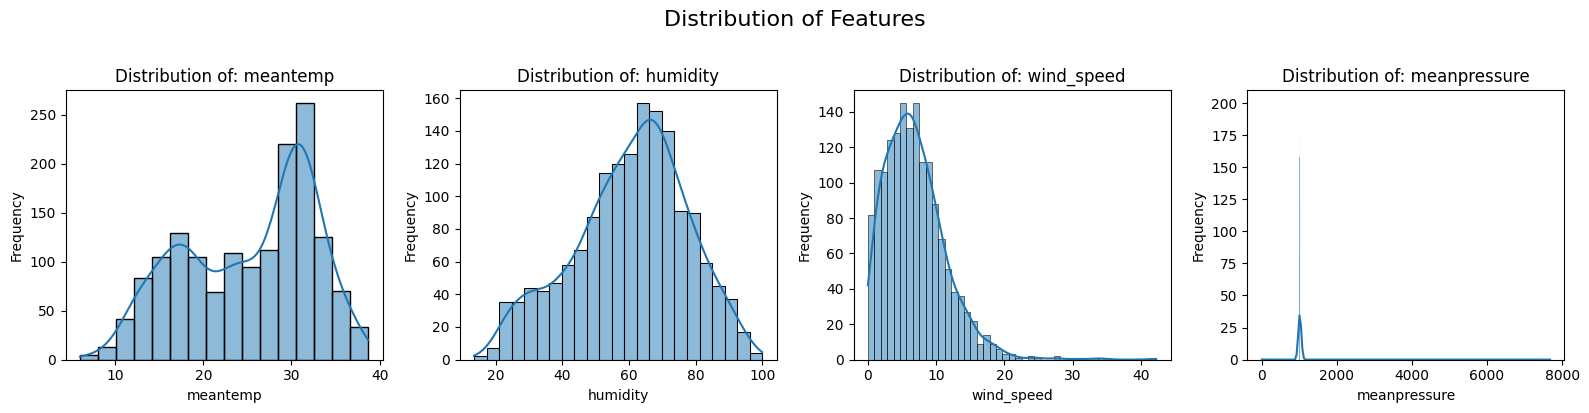

In [9]:
# Histogram for each feature except Date
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 4))
fig.suptitle('Distribution of Features', fontsize=16, y=1.02)

for i, col in enumerate(Train_df.columns[1:]):
    sns.histplot(data=data, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of: {col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)

plt.tight_layout()
plt.show()

**meanpressure** looks somehow, let's inspect with a boxplot.

Text(0.5, 1.0, 'Boxplot Highlighting Issues with Mean Atmospheric Pressure')

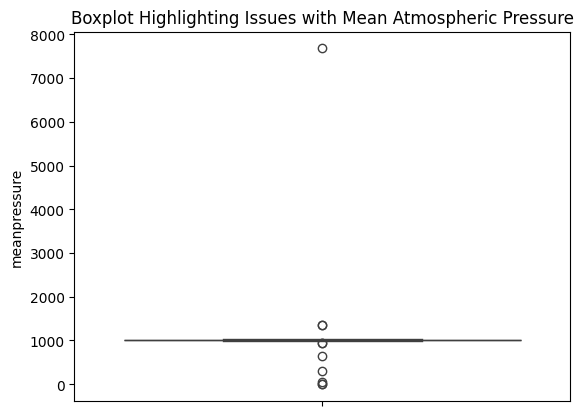

In [10]:
sns.boxplot(data=data, y="meanpressure")
plt.title("Boxplot Highlighting Issues with Mean Atmospheric Pressure")

The pressure values show unrealistic readings for atmospheric pressure in India. In reality, an expected range is around 980-1020 hPa (≈ 0.97-1.02 atm), some values are extreme, ranging from -3.04 to 7679.33 hPa, resulting in an abnormally high standard deviation. **Most data points are even clustered within this realistic range.**
Let's find out what happening with these unrealistic records:

In [11]:
df = data[~((data['meanpressure'] > 900) & (data['meanpressure'] < 1100))]
df

,index,date,meantemp,humidity,wind_speed,meanpressure
1182,1182,2016-03-28,25.933333,52.800000,6.546667,7679.333333
1309,1309,2016-08-02,30.687500,72.125000,6.375000,310.437500
1321,1321,2016-08-14,28.933333,83.700000,6.370000,633.900000
1323,1323,2016-08-16,31.333333,66.416667,14.666667,-3.041667
1362,1362,2016-09-24,31.240000,66.480000,5.496154,1352.615385
1416,1416,2016-11-17,21.730769,51.730769,11.550000,1350.296296
1427,1427,2016-11-28,22.454545,37.318182,9.185714,12.045455
1462,0,2017-01-01,15.913043,85.869565,2.743478,59.000000


Let's treat these pressure values as outliers due to measurement errors since they are not **physically plausible for surface atmospheric pressure in Delhi or anywhere at sea level on Earth**. We will replace them with missing values (NaN) and fill them using linear interpolation between the previous day and the day afterwards.

Text(0.5, 1.0, 'Mean Atmospheric Pressure (after cleaning & interpolation)')

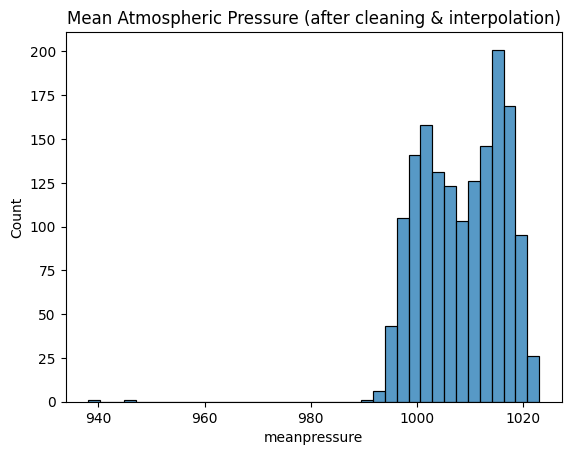

In [12]:
mask = (data['meanpressure'] < 900) | (data['meanpressure'] > 1100)
data.loc[mask, 'meanpressure'] = np.nan
# fill outliers with interpolated pressures
data['meanpressure'] = data['meanpressure'].interpolate()
# histogram of pressure
sns.histplot(data=data, x="meanpressure")
plt.title("Mean Atmospheric Pressure (after cleaning & interpolation)")

Next, we will check to ensure that the data does not contain duplicate entries. If it does, we will remove them.

In [13]:
dup_counts = data['date'].value_counts()
dup_counts = dup_counts[dup_counts > 1]
print(dup_counts)
#Show a bit of the duplicate records for inspection
dupes = data[data['date'].duplicated(keep=False)].sort_values('date')
dupes.head(4)

date
2017-01-01    2
Name: count, dtype: int64


,index,date,meantemp,humidity,wind_speed,meanpressure
1461,1461,2017-01-01,10.000000,100.000000,0.000000,1016.000000
1462,0,2017-01-01,15.913043,85.869565,2.743478,1017.138889


The two datasets intersect on January 1st, 2017, resulting in duplicate entries for that date. To preserve uniform time spacing, the duplicate measurements will be replaced with their average value.

In [14]:
# Group by Date, replace multiple occurrence with mean.
data = data.groupby('date', as_index=False).mean()

Next, we will check to ensure that the data is equally spaced (regular interval) as this is essential for time series.

In [15]:
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values('date')
data['diff'] = data['date'].diff()
data['diff'].value_counts()

,count
diff,
1 days,1574


### **3. Exploratory Data Analysis**

Next, let's do a brief exploratory analysis to understand the temporal behavior of the response variable (**mean_temp**).
This step focuses on visualizing overall trends and seasonality, examining feature relationships, and analyzing autocorrelation to confirm temporal dependencies.

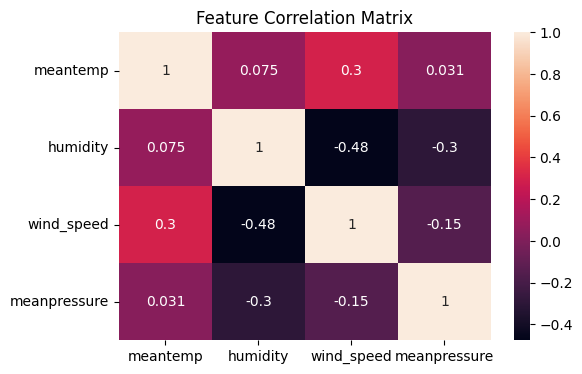

In [16]:
#feature correlation
plt.figure(figsize=(6,4))
correlation = df[['meantemp','humidity','wind_speed','meanpressure']].corr()
sns.heatmap(correlation, annot=True)
plt.title('Feature Correlation Matrix')
plt.show()

Let's check the seasonality, trend and residual behaviour using time series decomposition from statsmodel.

> **Citation:**
The following code block is adapted from Professor Michael Pyrcz (@GeostatsGuy),
[Time Series Analysis and Modeling]((https://geostatsguy.github.io/MachineLearningDemos_Book/MachineLearning_time_series.html) section in the
Applied Machine Learning in Python E-book.

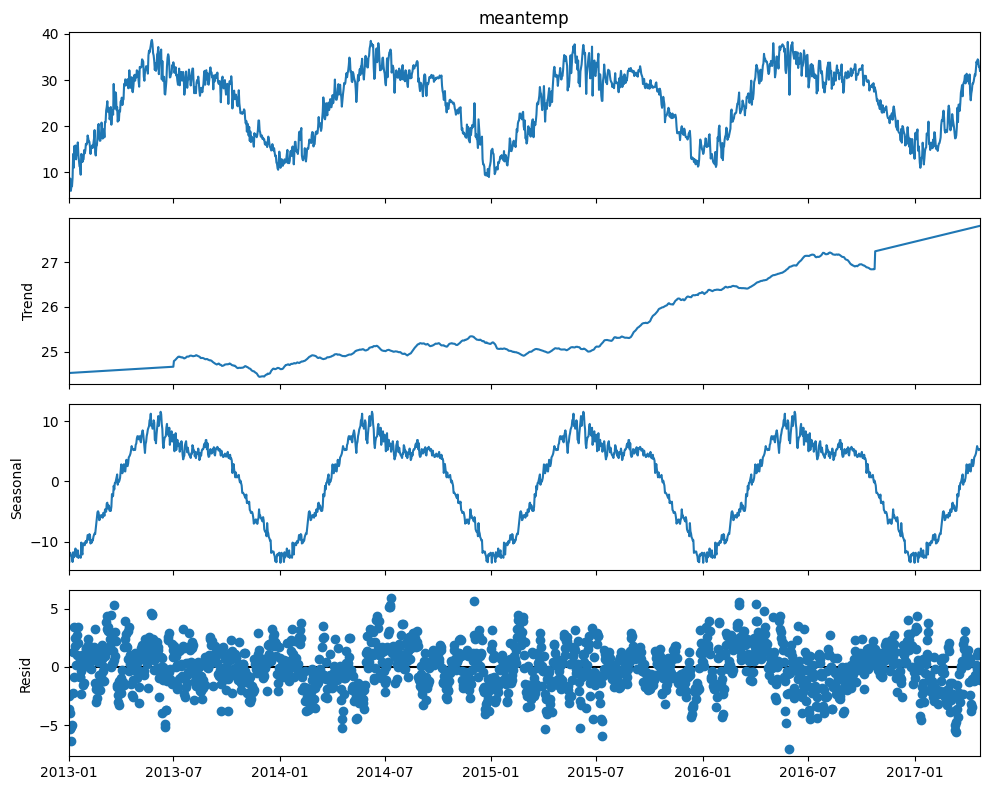

In [17]:
#Seasonality and trend in response feature
sorted_data = data.sort_values('date')
sorted_data.index = sorted_data['date']
decomposition = seasonal_decompose(sorted_data['meantemp'],model='additive',
                          period=365, # daily data → annual seasonality
                          extrapolate_trend='freq' # extend trend to edges for nicer plot
)
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.tight_layout(); plt.show()

The temperature data shows clear cyclic patterns and an overall upward trend. To better understand how strongly today's temperature depends on previous days, we use ACF and PACF plots to examine its autocorrelation structure. This helps us choose an appropriate lookback window for the BiLSTM model. **A lookback is the number of past time steps we include as input to the model so it can learn patterns and dependencies leading up to the prediction.**

> **Citation:**
The following code block is adapted from **Kaggle Grandmaster Leonie's (@iamleonie)** demonstration notebook,
[Time Series: Interpreting ACF and PACF]((https://www.kaggle.com/code/iamleonie/time-series-interpreting-acf-and-pacf).


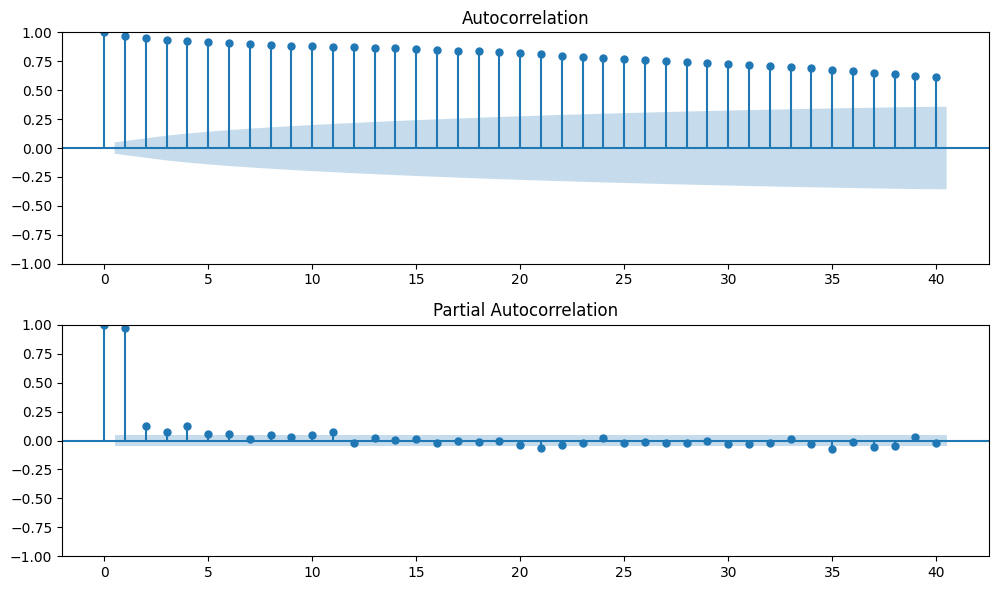

In [18]:
fig, ax = plt.subplots(2, 1, figsize=(10,6))
plot_acf(data['meantemp'], lags=40, ax=ax[0]) #Auto-correlation function
plot_pacf(data['meantemp'], lags=40, ax=ax[1]) #Partial Auto-correlation function
plt.tight_layout()
plt.show()

The partial auto-correlation function indicates a short-term direct dependency (~2-3 days),
while the auto-correlation function shows a slow overall decay, meaning the broader trend extends up to ~30 days. **Therefore, we will use a 30-day lookback for the BiLSTM model to capture both short and gradual trends.**


### **4. Feature Engineering**

Since this project simply aims to **demonstrate the BiLSTM architecture**, extensive feature engineering was deemed unnecessary.
The data will simply be sorted chronologically and normalized, ensuring proper sequence order and stable network training.

In [19]:
# Model Development and Hold-out split
sorted_data = sorted_data.reset_index(drop=True) #drop index used for seasonality plot
#re-split combined dataset chronologically using the same cutoff date from the original dataset
development_data = sorted_data[sorted_data['date'] <= Train_df.date.values[-2]] # Before 2017-01-01
hold_out  = sorted_data[sorted_data['date'] >=  Test_df.date.values[0]] # 2017-01-01 and after

print("Data for model development: ",development_data.shape); print("Hold out test set: ",hold_out.shape);

Data for model development:  (1461, 7)
Hold out test set:  (114, 7)


**Random shuffling or splitting isn't suitable for time series data** since temporal order must be preserved. So we will use the first 80% of records for training and the last 20% for validation to maintain the natural chronological sequence of the data.

In [20]:
# create training and validation sets (80:20)
train_size = int(development_data.shape[0] * 0.8)
df_train, df_val = development_data.iloc[:train_size,:], development_data.iloc[train_size:,:]
print("Data for training: ",df_train.shape); print("Data for validation: ", df_val.shape)

Data for training:  (1168, 7)
Data for validation:  (293, 7)


Neural networks require scaling of both inputs and targets, so we use separate scalers for each. This lets us inverse-transform the model's predictions cleanly without needing to pass other features.

We will also include temperature from the previous 30 days as one of the input features, because the recent temperature history is highly predictive of the next day's temperature. This is not data leakage, the model only sees past temperatures, never future values, so all information remains chronologically valid.

In [21]:
#feature scaling
x_scaler = MinMaxScaler(feature_range=(0, 1))
y_scaler = MinMaxScaler(feature_range=(0, 1))

input_features = ['humidity', 'wind_speed', 'meanpressure','meantemp']
resp_features = ['meantemp']


In [22]:
#fit scalers on training set
X_train_scaled = x_scaler.fit_transform(df_train[input_features].values)
y_train_scaled = y_scaler.fit_transform(df_train[resp_features].values.reshape(-1,1))

#Transform validation set using parameters from training set.
X_val_scaled = x_scaler.transform(df_val[input_features].values)
y_val_scaled = y_scaler.transform(df_val[resp_features].values.reshape(-1,1))

#Transform test set using parameters from training set.
hold_out_features_scaled = x_scaler.transform(hold_out[input_features].values)
hold_out_target_scaled = y_scaler.transform(hold_out[resp_features].values.reshape(-1,1))

### **5. Architecture and Data Sequence Development**

With the data prepared, we can now build the model. BiLSTMs require inputs to be organized as sequential, time-ordered windows, so we use a 30-day window to predict the next day's temperature and train with a batch size of 16. I have created a custom *SequenceDataset* and *build_data_loaders* function to efficiently create these sliding windows, which is the standard PyTorch approach for handling sequence data.

> **Citation:**
The following code block is adapted from **Kaggle Dataset Expert Suraj's (@suraj520)** discussion post,
[Creating custom dataset and dataloader class in PyTorch](https://www.kaggle.com/discussions/general/407993).



In [23]:
# Pytorch Models require custom dataset in this form
class SequenceDataset(Dataset):
    def __init__(self, features, target, lookback=30):
        self.features = features
        self.target = target
        self.lookback = lookback

    def __len__(self):
        return len(self.features) - self.lookback

    def __getitem__(self, idx):
        X = self.features[idx:idx + self.lookback] # 30 days of features
        y = self.target[idx + self.lookback] # next day's temp
        return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

In [24]:
# create dataloader for our pytorch model
def build_data_loaders(features, target, lookback, batch_size):
    sequence_dataset = SequenceDataset(features, target, lookback)
    data_loader = DataLoader(sequence_dataset, batch_size=batch_size, shuffle=False) # No shuffling to keep order
    return data_loader

Now, let's create dataloaders for training, validation and testing set. These dataloaders must honor the data sequence. PyTorch's [DataLoaders](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html) are used to efficiently batch, shuffle, and feed dataset samples to the model during training and evaluation.

In [25]:
lookback = 30
batch_size = 16
train_dl = build_data_loaders(X_train_scaled, y_train_scaled, lookback, batch_size)
val_dl = build_data_loaders(X_val_scaled, y_val_scaled, lookback, batch_size)
test_dl = build_data_loaders(hold_out_features_scaled, hold_out_target_scaled, lookback, batch_size)

Let's see what a single batch sequence looks like:

Each batch contains 16 sequences, where each sequence is 30 days × 4 features, and each sequence has 1 target value representing the temperature on the following day.

In [26]:
for xb, yb in train_dl:
    print("Shape of a single sequence (30 day lookback, batch size = 16)")
    print("features ",xb.shape); print("targets: ",yb.shape)
    break

Shape of a single sequence (30 day lookback, batch size = 16)
features  torch.Size([16, 30, 4])
targets:  torch.Size([16, 1])


**Architecture overview:**

- A single bidirectional LSTM layer processes each sequence forward and backward, capturing patterns from both directions.
- Each direction has 64 hidden units, producing 128 combined nodes (64 forward + 64 backward).
- A final fully connected layer maps these 128 features to a single temperature prediction.

I have implemented this architecture in the custom *BiLSTM* class below:


In [27]:
# Bidirectional LSTM model
class BiLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, output_dim=1):
        super(BiLSTM, self).__init__()
        # Bidirectional LSTM layer
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers, batch_first=True, bidirectional=True)
        # Fully connected layer to map the LSTM output to the target dimension
        self.fc = nn.Linear(hidden_dim*2, output_dim)

    def forward(self, x):
        # Pass input through the LSTM layer
        out, _ = self.lstm(x)
        # Take output from the last time step only
        out = out[:, -1, :]
        # Map to final output dimension
        out = self.fc(out)
        return out

Alright, going forward, we must select a computation device (GPU if available, otherwise CPU) and move the BiLSTM model onto it so training can run efficiently. Let's also set our loss function to the L2 Norm (MSE).

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#loss function = MSE
criterion = nn.MSELoss()

It is important that we monitor the validation loss during training. So we will use the idea of early stopping. I have defined a class to monitor the validation loss and keeps track of the best-performing model weights during training. If the validation loss stops improving for a specified number of epochs (patience), training is halted and the model is restored to its best state.

In [29]:
# Stops training if validation loss doesn't improve after a certain number of epochs (patience) and restores best weights.
class EarlyStopping:
    def __init__(self, patience=5, loss_tolerance=1e-5):
        self.patience = patience
        self.loss_tolerance = loss_tolerance
        self.best = None
        self.counter = 0
        self.best_state = None
        self.stopped = False

    def step(self, val_loss, model):
        if self.best is None or (self.best - val_loss) > self.loss_tolerance:
            self.best = val_loss
            self.counter = 0
            #extract weights of the best model so far
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stopped = True
                # restore best weights
                model.load_state_dict(self.best_state)

### **6. Model Training and Evaluation**

We wrap the entire training process in a train_model function so the workflow is easy to reuse. Inside this function, we create a fresh BiLSTM model, set up the Adam optimizer, attach a learning rate scheduler, and enable early stopping. During each epoch, the model learns from the training batches and is then evaluated on the validation set.

**During prediction, the network runs only the forward pass, so we disable backpropagation because the weights should remain fixed.**


In [31]:
def train_model(model, train_dl, val_dl,lr=3e-3, max_epochs=100, verbose=True):

    #Adam optimizer with learning rate scheduler
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    #initialize the early stopper
    early = EarlyStopping(patience=10, loss_tolerance=1e-5)

    train_losses, val_losses = [], []

    # Training loop
    for epoch in range(1, max_epochs + 1):
        # Train
        model.train()
        running = 0.0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            #gradient clipping for stability
            clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running += loss.item()
        train_loss = running / len(train_dl)
        train_losses.append(train_loss)

        # Validate
        model.eval()
        val_running = 0.0
        with torch.no_grad(): #freeze and disable weight's gradient update
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                val_running += loss.item()
        val_loss = val_running / len(val_dl)
        val_losses.append(val_loss)

        scheduler.step(val_loss)

        if verbose:
            print(f"Epoch {epoch:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

        # Early stopping
        early.step(val_loss, model)
        if early.stopped:
            if verbose:
                print(f"Early stopping (patience= {early.patience}). Restored best weights.")
            break

    best_val = min(val_losses)
    return best_val, train_losses, val_losses, model

In [32]:
#initialize the BiLSTM model
model = BiLSTM(input_dim=len(input_features)).to(device)
#Train
best_val, train_losses, val_losses, model = train_model(model, train_dl, val_dl,lr=3e-3, max_epochs=500, verbose=True)

Epoch 001 | train_loss=0.079469 | val_loss=0.032957
Epoch 002 | train_loss=0.019341 | val_loss=0.004622
Epoch 003 | train_loss=0.004229 | val_loss=0.003927
Epoch 004 | train_loss=0.003442 | val_loss=0.004665
Epoch 005 | train_loss=0.003516 | val_loss=0.006199
Epoch 006 | train_loss=0.003625 | val_loss=0.006303
Epoch 007 | train_loss=0.003464 | val_loss=0.006062
Epoch 008 | train_loss=0.003129 | val_loss=0.003288
Epoch 009 | train_loss=0.002843 | val_loss=0.002993
Epoch 010 | train_loss=0.002784 | val_loss=0.003084
Epoch 011 | train_loss=0.002777 | val_loss=0.003259
Epoch 012 | train_loss=0.002791 | val_loss=0.003411
Epoch 013 | train_loss=0.002809 | val_loss=0.003585
Epoch 014 | train_loss=0.002646 | val_loss=0.002712
Epoch 015 | train_loss=0.002639 | val_loss=0.002605
Epoch 016 | train_loss=0.002672 | val_loss=0.002576
Epoch 017 | train_loss=0.002692 | val_loss=0.002559
Epoch 018 | train_loss=0.002696 | val_loss=0.002552
Epoch 019 | train_loss=0.002685 | val_loss=0.002560
Epoch 020 | 

Training is done. Now, let's plot the validation and training losses over the entire training epochs using the **plot_epoch** function defined earlier.

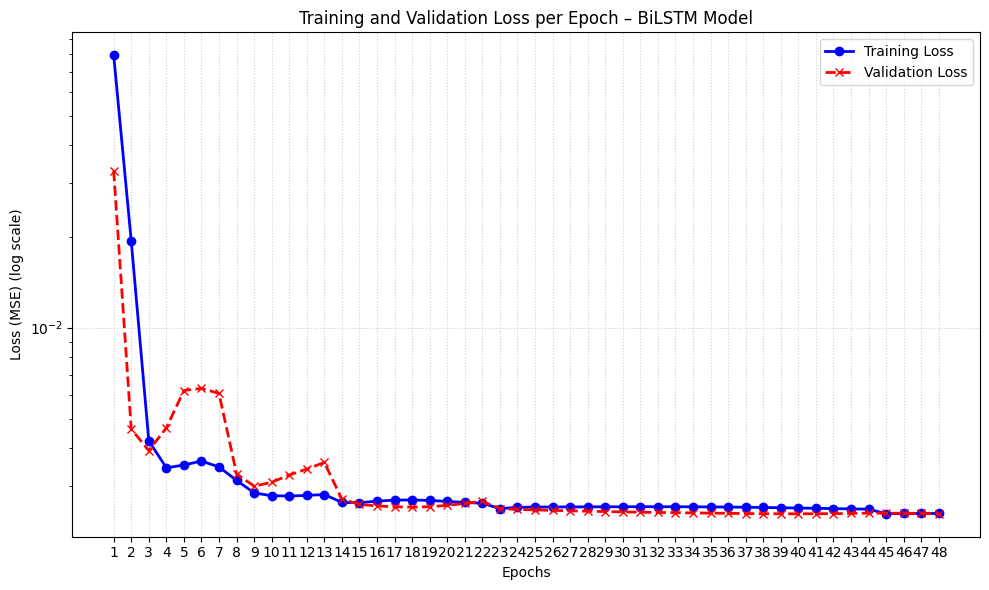

In [33]:
plot_epoch(train_losses, val_losses, model_name = "BiLSTM Model", log_scale=True)

The validation loss steadily decreases, which shows the training is stable. Since the training and validation losses remain close, the model is not overfitting.

Now we can use the model to make predictions on the test set. **During prediction we must disable backpropagation again because we only need the forward pass, not gradient updates.**

In [34]:
model.eval() #put model in evaluation mode
test_running = 0.0
test_prediction, ground_truth = [], []

with torch.no_grad(): # disable gradient tracking
    for xb, yb in test_dl:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb)
        test_running += criterion(preds, yb).item()
        test_prediction.append(preds.cpu().numpy())
        ground_truth.append(yb.cpu().numpy())

# Test MSE in normalized scale
test_loss = test_running / len(test_dl)
print(f"Test MSE (In Normalized Scale): {test_loss:.6f}")

Test MSE (In Normalized Scale): 0.002651


Because our targets were scaled before training, the loss we see during training is in a normalized range and can look artificially small. To understand the model's real accuracy, we must convert the predictions back to the original units and evaluate the loss there. We will use the **eval_original_units** that was defined earlier.

In [35]:
# reshape to predictions and ground truth to 1 dimension array.
all_preds = np.concatenate(test_prediction).reshape(-1, 1)
all_targets = np.concatenate(ground_truth).reshape(-1, 1)

# performance metrics in original units
preds_inv, targets_inv , metrics = eval_original_units(all_preds, all_targets, y_scaler)
print("Evaluation Metrics in Original Temperature Scale: ",metrics)

Evaluation Metrics in Original Temperature Scale:  {'MSE': 3.126650810241699, 'MAE': 1.4461967945098877, 'RMSE': 1.768233810965535}


Now we can compare the model's predictions to the true values. Since creating sequences removes the first 30 days of data, we need to drop those initial points before plotting so the predictions and targets align correctly.

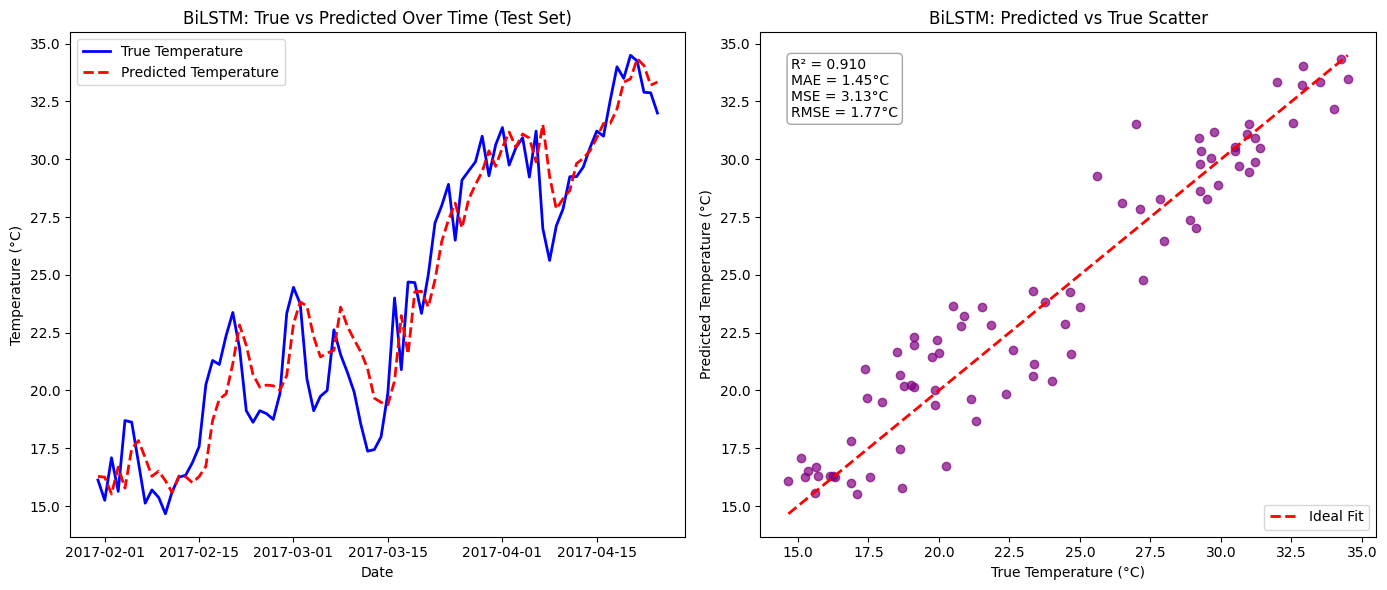

In [36]:
test_dates = hold_out['date'].iloc[lookback:].reset_index(drop=True)
plot_predictions(test_dates=test_dates,true_vals=targets_inv,pred_vals=preds_inv,model_name="BiLSTM")

We have good alignment but this can be improved through hyperparameter tuning.

### **6. Hyper-Parameter Tuning**

We want our hyperparameter tuning to be based on cross-validation. However, since the data is a sequence (time series), we cannot use KFold, as we need to preserve the temporal ordering of observations. Scikit-learn provides a time-aware cross-validation method called [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html), which incrementally expands the training window and moves the validation window forward in time.

![TimeSeries Split](https://towardsdatascience.com/wp-content/uploads/2022/12/1U6GlQEF9Wk2vlbFetQRsYg.png)

> **Citation:**
The image above was taken from the [4 Things to Do When Applying Cross-Validation with Time Series](https://towardsdatascience.com/4-things-to-do-when-applying-cross-validation-with-time-series-c6a5674ebf3a/) article on medium.



In [37]:
X_all = development_data[input_features].values
y_all = development_data[resp_features].values

We will first split the raw arrays using TimeSeriesSplit and then build the PyTorch SequenceDataset and dataloaders within each fold.

> **Citation:**
The code below is adapted from the example on page 16 of **10c_Tuning_Hyperparameters.pdf**, part of Prof. Michael Pyrcz's PGE 383 course materials.

In [38]:
### Evaluate one set of hyperparameters using TimeSeriesSplit CV.
def evaluate_hyperparameter(config, X_all, y_all):
    fold_val_losses = []

    for fold, (train_idx, valid_idx) in enumerate(tscv.split(X_all)):
        # Split raw arrays
        X_train, y_train = X_all[train_idx], y_all[train_idx]
        X_valid, y_valid = X_all[valid_idx], y_all[valid_idx]

        X_train_saled = x_scaler.fit_transform(X_train)
        X_valid_scaled = x_scaler.transform(X_valid)

        y_train_scaled = y_scaler.fit_transform(y_train)
        y_valid_scaled = y_scaler.transform(y_valid)

        # Build sequence datasets + loaders for this fold
        train_dl = build_data_loaders(X_train_saled, y_train_scaled, lookback, batch_size)
        val_dl   = build_data_loaders(X_valid_scaled, y_valid_scaled, lookback, batch_size)

        # Fresh model for this fold
        model = BiLSTM(input_dim=X_all.shape[1],hidden_dim=config["hidden_dim"],
                       num_layers=config["num_layers"],output_dim=1).to(device)

        # Train quietly, get best val loss for this fold
        best_val_loss, _, _, _ = train_model(model, train_dl,val_dl,
              lr=3e-3,max_epochs=1000, verbose=False,      # no prints during tuning
        )

        fold_val_losses.append(best_val_loss)

    # Return average validation loss across folds
    return float(np.mean(fold_val_losses))


Let's define our hyperparameter spaces, we will tune:
- Number of nodes in hidden layers
- Number of hidden layers
- learning rate

In [39]:
# For every split, the last 100 sequences become the validation set
tscv = TimeSeriesSplit(n_splits=5, test_size=100, gap=0)

# Parameter search space
param_grid = {
    "hidden_dim": [32, 64, 128, 256],
    "num_layers": [1, 2]
}

We will manually loop through all hyperparameter combinations and choose the best one

In [40]:
best_config = None
best_score = float("inf")
all_results = []

for config in ParameterGrid(param_grid):
    print(f"\nEvaluating hyperparameters: {config}")
    avg_val_loss = evaluate_hyperparameter(config, X_all, y_all)
    print(f"Average CV val loss: {avg_val_loss:.6f}")

    all_results.append({**config, "avg_val_loss": avg_val_loss})

    if avg_val_loss < best_score:
        best_score = avg_val_loss
        best_config = config

print("\nBest hyperparameters from TimeSeriesSplit CV:")
print(best_config)
print("Best average validation loss:", best_score)



Evaluating hyperparameters: {'hidden_dim': 32, 'num_layers': 1}
Average CV val loss: 0.002229

Evaluating hyperparameters: {'hidden_dim': 32, 'num_layers': 2}
Average CV val loss: 0.002749

Evaluating hyperparameters: {'hidden_dim': 64, 'num_layers': 1}
Average CV val loss: 0.002166

Evaluating hyperparameters: {'hidden_dim': 64, 'num_layers': 2}
Average CV val loss: 0.002502

Evaluating hyperparameters: {'hidden_dim': 128, 'num_layers': 1}
Average CV val loss: 0.002196

Evaluating hyperparameters: {'hidden_dim': 128, 'num_layers': 2}
Average CV val loss: 0.002497

Evaluating hyperparameters: {'hidden_dim': 256, 'num_layers': 1}
Average CV val loss: 0.002863

Evaluating hyperparameters: {'hidden_dim': 256, 'num_layers': 2}
Average CV val loss: 0.002963

Best hyperparameters from TimeSeriesSplit CV:
{'hidden_dim': 64, 'num_layers': 1}
Best average validation loss: 0.002165560668800026


### **6. Refit Best Model**

After selecting the best hyperparameters via TimeSeriesSplit cross-validation, we retrain a final BiLSTM model on the entire **training+validation sequence** using the best hyperparameters. To benefit from validation based early stopping, we will hold out the last 10%.



In [41]:
# Join train and validation sets
X_full = np.concatenate([X_train_scaled, X_val_scaled], axis=0)
y_full = np.concatenate([y_train_scaled, y_val_scaled], axis=0)

val_frac = 0.1  # use last 10% as internal validation
split_idx = int((1 - val_frac) * len(X_full))

X_tr_full, X_va_small = X_full[:split_idx], X_full[split_idx:]
y_tr_full, y_va_small = y_full[:split_idx], y_full[split_idx:]

train_dl = build_data_loaders(X_tr_full, y_tr_full, lookback, batch_size)
val_dl = build_data_loaders(X_va_small, y_va_small, lookback, batch_size)


In [42]:
tuned_model = BiLSTM(
    input_dim=X_all.shape[1],
    hidden_dim=best_config["hidden_dim"],
    num_layers=best_config["num_layers"],
    output_dim=1,
).to(device)

best_val, train_losses, val_losses, tuned_model = train_model(tuned_model, train_dl, val_dl,lr=3e-3, max_epochs=500, verbose=True)

Epoch 001 | train_loss=0.092288 | val_loss=0.015060
Epoch 002 | train_loss=0.014035 | val_loss=0.017976
Epoch 003 | train_loss=0.007816 | val_loss=0.003332
Epoch 004 | train_loss=0.004918 | val_loss=0.003189
Epoch 005 | train_loss=0.003628 | val_loss=0.002659
Epoch 006 | train_loss=0.003409 | val_loss=0.002888
Epoch 007 | train_loss=0.003357 | val_loss=0.002731
Epoch 008 | train_loss=0.003371 | val_loss=0.004400
Epoch 009 | train_loss=0.003493 | val_loss=0.001629
Epoch 010 | train_loss=0.006764 | val_loss=0.024948
Epoch 011 | train_loss=0.013430 | val_loss=0.021319
Epoch 012 | train_loss=0.007634 | val_loss=0.002929
Epoch 013 | train_loss=0.003812 | val_loss=0.002015
Epoch 014 | train_loss=0.002954 | val_loss=0.001621
Epoch 015 | train_loss=0.002864 | val_loss=0.001561
Epoch 016 | train_loss=0.002813 | val_loss=0.001552
Epoch 017 | train_loss=0.002785 | val_loss=0.001551
Epoch 018 | train_loss=0.002768 | val_loss=0.001558
Epoch 019 | train_loss=0.002763 | val_loss=0.001573
Epoch 020 | 

Let's evaluate the tuned model on the hold-out test set, which was never used during tuning or training, to estimate true generalization performance.

In [43]:
tuned_model.eval()
all_preds, all_targs = [], []

with torch.no_grad():
    for xb, yb in test_dl:
        xb, yb = xb.to(device), yb.to(device)
        preds = tuned_model(xb)
        all_preds.append(preds.cpu().numpy())
        all_targs.append(yb.cpu().numpy())

preds = np.concatenate(all_preds).reshape(-1, 1)
targs = np.concatenate(all_targs).reshape(-1, 1)

preds_inv, targs_inv, metrics = eval_original_units(preds, targs, y_scaler)
print("Test metrics:", metrics)

Test metrics: {'MSE': 3.0883636474609375, 'MAE': 1.4340507984161377, 'RMSE': 1.7573740772701005}


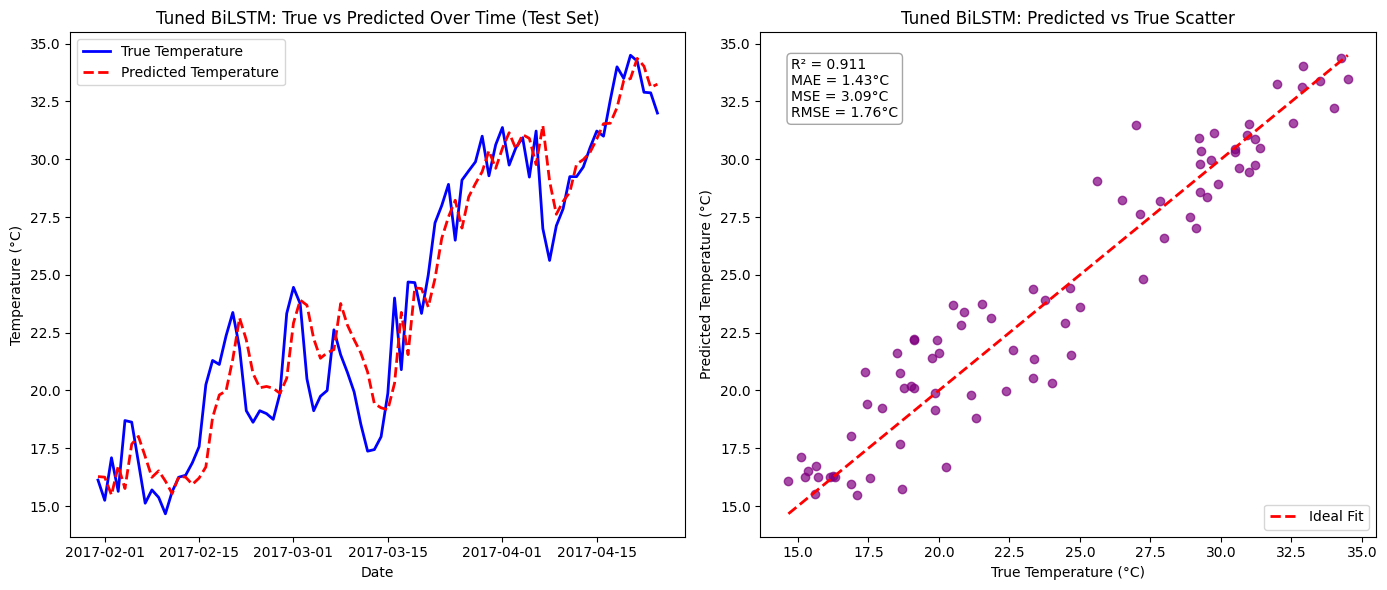

In [44]:
test_dates = hold_out['date'].iloc[lookback:].reset_index(drop=True)
plot_predictions(test_dates=test_dates,true_vals=targs_inv,pred_vals=preds_inv,model_name="Tuned BiLSTM")

## **Results**

This project demonstrated the full end-to-end workflow for applying a Bidirectional LSTM (BiLSTM) network to time-series forecasting. After preparing the data, constructing sliding windows, and tuning the model, the final model achieved the following performance on the hold-out test set (reported in original temperature units):

| Metric        | Value |
| ------------- | ----- |
| **MAE** (°C)  | 1.43  |
| **RMSE** (°C) | 1.76  |
| **R² Score**  | 0.911 |

These results show that the BiLSTM effectively learned the long-range temporal patterns present in the 30 day lookback window, producing stable and accurate next-day temperature forecasts. The predicted temperature curve closely follows the true observations, capturing both day-to-day variability and broader seasonal trends.

Training and validation loss curves also confirmed smooth convergence, while early stopping and learning-rate scheduling helped prevent overfitting and ensured good generalization performance.


#### **About ME**

I am a graduate student in the Hildebrand Department of Petroleum and Geosystems Engineering at The University of Texas at Austin, working on Spatial Data Analytics and Machine Learning for Subsurface Resource Modeling.

I hope this workflow was helpful!

Alexander

aifenaike@utexas.edu

#### **About the Supervising Professor**

Michael Pyrcz is a professor in the [Cockrell School of Engineering](https://cockrell.utexas.edu/faculty-directory/alphabetical/p), and the [Jackson School of Geosciences](https://www.jsg.utexas.edu/researcher/michael_pyrcz/), at [The University of Texas at Austin](https://www.utexas.edu/), where he researches and teaches subsurface, spatial data analytics, geostatistics, and machine learning. Michael is also,

* the principal investigator of the [Energy Analytics](https://fri.cns.utexas.edu/energy-analytics) freshmen research initiative and a core faculty in the Machine Learn Laboratory in the College of Natural Sciences, The University of Texas at Austin

* an associate editor for [Computers and Geosciences](https://www.sciencedirect.com/journal/computers-and-geosciences/about/editorial-board), and a board member for [Mathematical Geosciences](https://link.springer.com/journal/11004/editorial-board), the International Association for Mathematical Geosciences.

Michael has written over 70 [peer-reviewed publications](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en), a [Python package](https://pypi.org/project/geostatspy/) for spatial data analytics, co-authored a textbook on spatial data analytics, [Geostatistical Reservoir Modeling](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) and author of two recently released e-books, [Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) and [Applied Machine Learning in Python: a Hands-on Guide with Code](https://geostatsguy.github.io/MachineLearningDemos_Book/intro.html).

All of Michael’s university lectures are available on his [YouTube Channel](https://www.youtube.com/@GeostatsGuyLectures) with links to 100s of Python interactive dashboards and well-documented workflows in over 40 repositories on his [GitHub account](https://github.com/GeostatsGuy), to support any interested students and working professionals with evergreen content. To find out more about Michael’s work and shared educational resources visit his [Website](www.michaelpyrcz.com).

#### Want to Work Together?

I hope this content is helpful to those that want to learn more about subsurface modeling, data analytics and machine learning. Students and working professionals are welcome to participate.

* Want to invite me to visit your company for training, mentoring, project review, workflow design and / or consulting? I'd be happy to drop by and work with you!

* Interested in partnering, supporting my graduate student research or my Subsurface Data Analytics and Machine Learning consortium (co-PI is Professor John Foster)? My research combines data analytics, stochastic modeling and machine learning theory with practice to develop novel methods and workflows to add value. We are solving challenging subsurface problems!

* I can be reached at mpyrcz@austin.utexas.edu.

I'm always happy to discuss,

*Michael*

Michael Pyrcz, Ph.D., P.Eng. Professor, Cockrell School of Engineering and The Jackson School of Geosciences, The University of Texas at Austin

More Resources Available at: [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)